# Mission 1 — Données et analyse exploratoire
**Projet Churn Telco — Master IA, Supervised Learning**

Objectifs de ce notebook : profiling, détection de fuite de données, analyse bivariée
et vérification graphique des hypothèses. Ce notebook est le socle sur lequel la
Mission 2 (pipeline) s'appuiera — aucune transformation apprise n'est effectuée ici,
uniquement de l'observation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.shape

(7043, 21)

## 1. Profiling général

In [2]:
print("Lignes:", df.shape[0], "| Colonnes:", df.shape[1])
print()
print(df.dtypes)

Lignes: 7043 | Colonnes: 21

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


**Doublons.** Aucun doublon de ligne ni de `customerID` (vérifié — 0 doublon sur les deux
critères). Pas d'action nécessaire.

In [3]:
print("Doublons (lignes complètes) :", df.duplicated().sum())
print("Doublons customerID :", df['customerID'].duplicated().sum())

Doublons (lignes complètes) : 0
Doublons customerID : 0


### Le piège `TotalCharges`

`TotalCharges` est typé `object` alors qu'il devrait être numérique — signe classique
d'une colonne polluée par des chaînes non convertibles. L'inspection montre que les
**11 valeurs problématiques correspondent exactement aux 11 clients avec `tenure == 0`**
(nouveaux clients, pas encore facturés). Ce n'est donc pas du "manquant aléatoire" :
c'est une conséquence logique et déterministe de l'ancienneté nulle.

**Décision documentée pour la Mission 2** : plutôt qu'une imputation par la médiane
(qui insérerait une valeur arbitraire ~1400€ sur des clients qui n'ont *objectivement*
rien payé), la valeur correcte à imputer est **0**, dictée par la connaissance métier et
non par une statistique du pipeline. C'est un exemple concret où la médiane
"techniquement correcte" serait en réalité une erreur de modélisation.

In [4]:
mask_bad = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print("Lignes avec TotalCharges non numérique :", mask_bad.sum())
display_cols = ['customerID','tenure','MonthlyCharges','TotalCharges','Churn']
df.loc[mask_bad, display_cols]

Lignes avec TotalCharges non numérique : 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_pct[missing_pct > 0]

TotalCharges    0.16
dtype: float64

**Features quasi-constantes.** Aucune variable catégorielle n'a de modalité
représentant plus de 98% des observations (vérifié programmatiquement ci-dessous) —
pas de feature à écarter pour absence de variance.

In [6]:
quasi_constant = []
for c in df.select_dtypes(include='object').columns:
    if c in ('customerID', 'Churn'):
        continue
    top_ratio = df[c].value_counts(normalize=True).iloc[0]
    if top_ratio > 0.98:
        quasi_constant.append((c, round(top_ratio, 4)))
print("Features quasi-constantes détectées :", quasi_constant if quasi_constant else "aucune")

Features quasi-constantes détectées : aucune


/tmp/ipykernel_550/2892000173.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


### Colinéarité numérique

`TotalCharges` est quasi-déterministe à partir de `tenure × MonthlyCharges`
(corrélation de 0.9996). Ce n'est pas une fuite (l'information est connue avant le
départ du client) mais une **redondance forte** : dans un modèle linéaire, garder les
trois colonnes brutes gonfle la variance des coefficients sans apporter d'information
nouvelle. Piste retenue pour la Mission 2 : remplacer `TotalCharges` par un ratio
`charges_par_mois_ancien = TotalCharges / (tenure + 1)` qui capture un signal différent
(charge moyenne réelle vs. charge actuelle) plutôt que de garder les 3 variables brutes.

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000

Corrélation TotalCharges vs (tenure * MonthlyCharges) : 0.9996


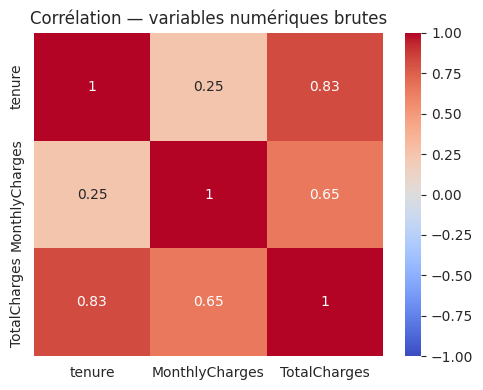

In [7]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
print(corr.round(3))

approx = df['tenure'] * df['MonthlyCharges']
r = np.corrcoef(df['TotalCharges'].fillna(0), approx)[0, 1]
print(f"\nCorrélation TotalCharges vs (tenure * MonthlyCharges) : {r:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Corrélation — variables numériques brutes')
plt.tight_layout()
plt.savefig('../notebooks/fig_correlation_numerique.png', dpi=120)
plt.show()

## 2. Détection de fuite de données

**Méthodologie.** Une fuite se manifeste typiquement par une feature dont le pouvoir
discriminant est anormalement élevé (AUC univarié proche de 1) — signe qu'elle encode,
directement ou indirectement, une information postérieure à l'événement prédit. Seuil
retenu : AUC > 0.90 = suspect, à investiguer manuellement.

Toutes les colonnes de ce dataset sont des attributs de compte connus **pendant** que
le client est actif (services souscrits, contrat, mode de paiement...) — aucune ne décrit
un événement postérieur à la résiliation (pas de motif de départ, pas de date de clôture).
La vérification quantitative ci-dessous confirme cette lecture qualitative.

In [8]:
df_enc = df.drop(columns=['customerID', 'Churn']).copy()
df_enc['TotalCharges'] = df_enc['TotalCharges'].fillna(0)
y = (df['Churn'] == 'Yes').astype(int)

cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))

auc_scores = {}
for c in df_enc.columns:
    auc = roc_auc_score(y, df_enc[c])
    auc_scores[c] = max(auc, 1 - auc)

auc_s = pd.Series(auc_scores).sort_values(ascending=False)
print("=== AUC univarié par feature (seuil suspect > 0.90) ===")
print(auc_s.round(3))
print()
suspects = auc_s[auc_s > 0.90]
print("Features suspectes :", list(suspects.index) if len(suspects) else "AUCUNE — pas de fuite détectée")

=== AUC univarié par feature (seuil suspect > 0.90) ===
tenure              0.740
Contract            0.739
OnlineSecurity      0.683
TechSupport         0.678
TotalCharges        0.650
OnlineBackup        0.624
MonthlyCharges      0.621
DeviceProtection    0.613
PaperlessBilling    0.607
Dependents          0.585
Partner             0.585
PaymentMethod       0.564
SeniorCitizen       0.563
StreamingMovies     0.524
StreamingTV         0.523
MultipleLines       0.522
InternetService     0.517
gender              0.505
PhoneService        0.504
dtype: float64

Features suspectes : AUCUNE — pas de fuite détectée


/tmp/ipykernel_550/2301178938.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_enc.select_dtypes(include='object').columns.tolist()


**Conclusion fuite de données** : le feature le plus discriminant seul (`Contract`,
`tenure`) plafonne à AUC ≈ 0.74 — largement sous le seuil suspect de 0.90. Aucune fuite
n'est détectée dans ce jeu de données. Ce résultat négatif est documenté explicitement
car l'absence de fuite ne doit jamais être *supposée*, elle doit être *vérifiée*.

## 3. Analyse bivariée et pouvoir discriminant (information mutuelle)

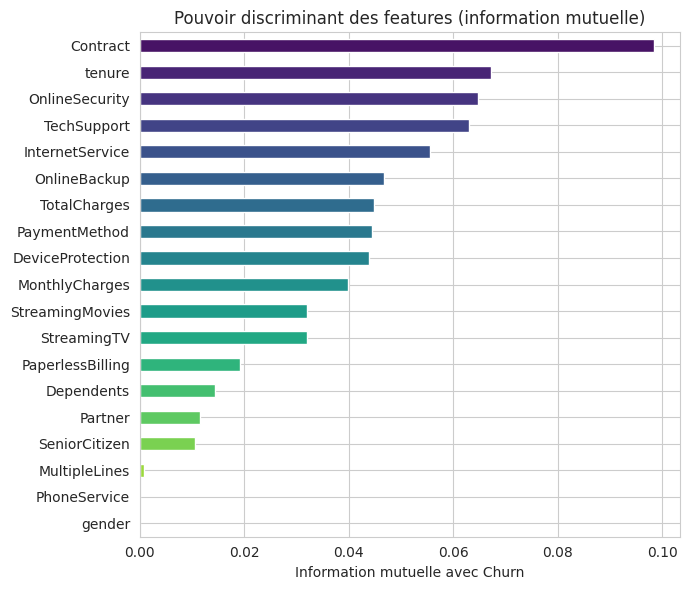

Top 5 features les plus prédictives :
Contract           0.098453
tenure             0.067288
OnlineSecurity     0.064677
TechSupport        0.063021
InternetService    0.055574
dtype: float64


In [9]:
discrete_mask = [c in cat_cols or c == 'SeniorCitizen' for c in df_enc.columns]
mi = mutual_info_classif(df_enc, y, discrete_features=discrete_mask, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=df_enc.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
mi_s.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(mi_s)))
ax.invert_yaxis()
ax.set_xlabel('Information mutuelle avec Churn')
ax.set_title('Pouvoir discriminant des features (information mutuelle)')
plt.tight_layout()
plt.savefig('../notebooks/fig_mutual_information.png', dpi=120)
plt.show()

print("Top 5 features les plus prédictives :")
print(mi_s.head(5))

**Top 5 features prédictives (information mutuelle)** : `Contract`, `tenure`,
`OnlineSecurity`, `TechSupport`, `InternetService`.

À l'inverse, `gender`, `PhoneService` et `MultipleLines` ont un pouvoir discriminant
quasi nul (MI ≈ 0, AUC ≈ 0.50) — candidats à l'élimination en Mission 2 au nom du
rasoir d'Occam, à confirmer par la variation du score de validation croisée (et non
supprimés ici sur la seule base de l'EDA).

## 4. Vérification graphique des hypothèses

Cinq hypothèses formulées avant observation des chiffres, puis vérifiées :

1. Les clients en contrat mensuel churnent davantage que ceux en engagement annuel/2 ans.
2. Les clients à faible ancienneté (`tenure`) churnent davantage que les clients anciens.
3. L'absence de services de sécurité en ligne (`OnlineSecurity`) est associée à un churn plus élevé (moindre "stickiness").
4. Les clients en fibre optique (`InternetService`) churnent davantage que les clients DSL.
5. Le paiement par chèque électronique (`PaymentMethod`) est associé à un churn plus élevé que les moyens de paiement automatisés.

/tmp/ipykernel_550/1220041103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette='rocket')
/tmp/ipykernel_550/1220041103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette='rocket')
/tmp/ipykernel_550/1220041103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rates.values, y=rates.index, ax=ax, palette='rocket')
/tmp/ipykernel_550/1220041103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

/tmp/ipykernel_550/1220041103.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 2], palette='Set2')


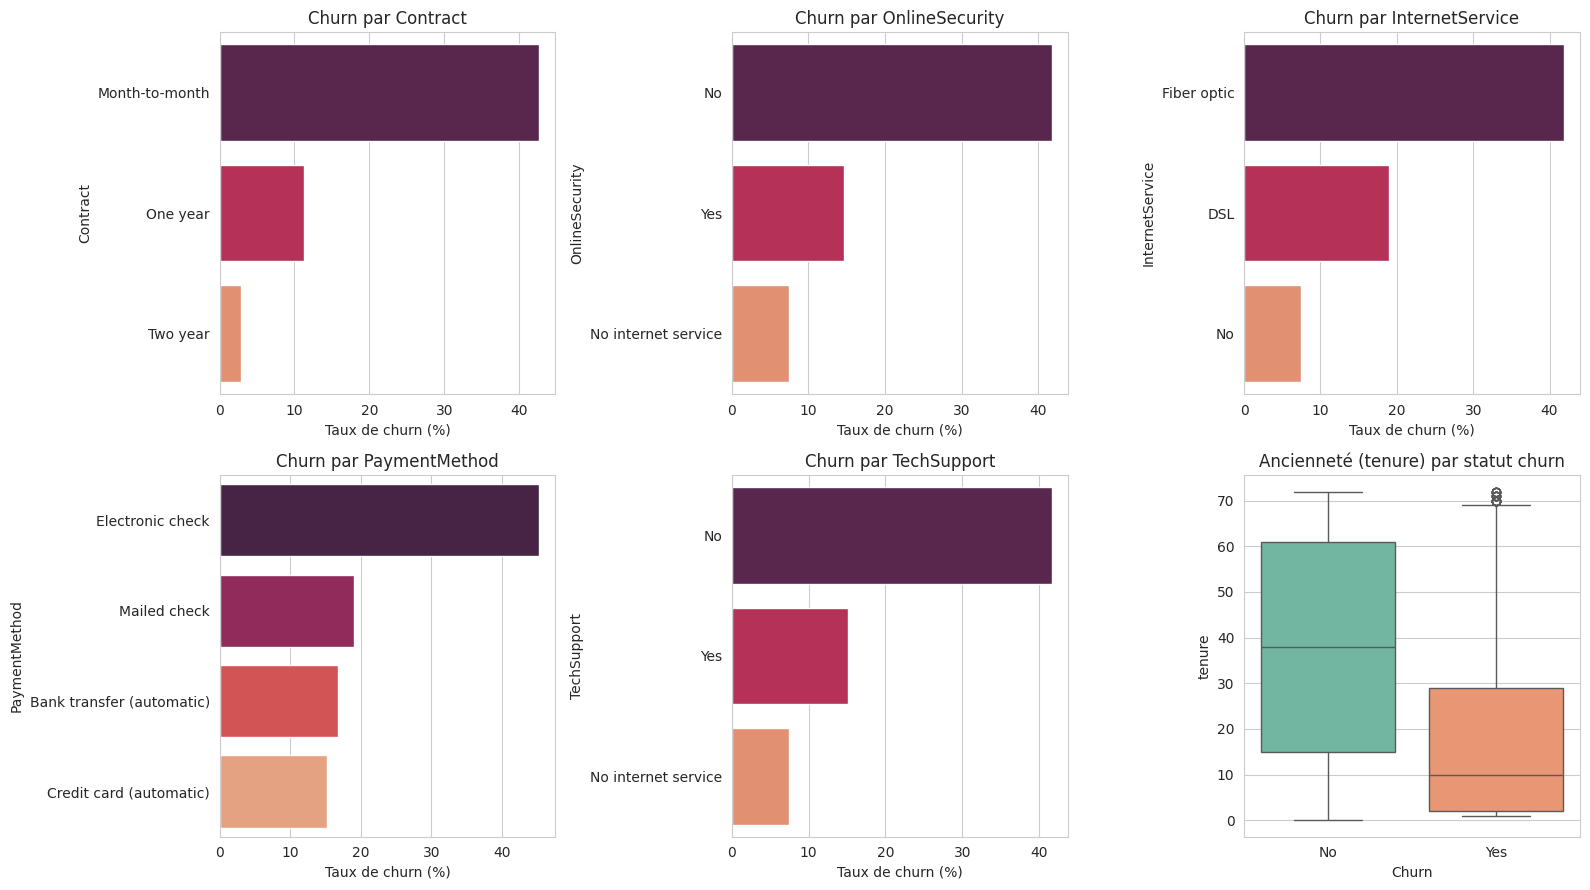

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

def plot_churn_rate(col, ax):
    rates = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette='rocket')
    ax.set_xlabel('Taux de churn (%)')
    ax.set_title(f'Churn par {col}')

plot_churn_rate('Contract', axes[0, 0])
plot_churn_rate('OnlineSecurity', axes[0, 1])
plot_churn_rate('InternetService', axes[0, 2])
plot_churn_rate('PaymentMethod', axes[1, 0])
plot_churn_rate('TechSupport', axes[1, 1])

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Ancienneté (tenure) par statut churn')

plt.tight_layout()
plt.savefig('../notebooks/fig_hypotheses_bivariee.png', dpi=120)
plt.show()

In [11]:
print("Médiane tenure  — Churn=No :", df.loc[df.Churn=='No','tenure'].median(),
      "| Churn=Yes :", df.loc[df.Churn=='Yes','tenure'].median())
print("Médiane charges — Churn=No :", df.loc[df.Churn=='No','MonthlyCharges'].median(),
      "| Churn=Yes :", df.loc[df.Churn=='Yes','MonthlyCharges'].median())

Médiane tenure  — Churn=No : 38.0 | Churn=Yes : 10.0
Médiane charges — Churn=No : 64.42500000000001 | Churn=Yes : 79.65


**Résultat des 5 hypothèses — toutes confirmées, avec des tailles d'effet importantes :**

| # | Hypothèse | Résultat chiffré | Statut |
|---|---|---|---|
| 1 | Contrat mensuel → plus de churn | Month-to-month 42.7% vs One year 11.3% vs Two year 2.8% | ✅ Confirmée, effet très marqué |
| 2 | Faible ancienneté → plus de churn | Médiane tenure : 10 mois (churners) vs 38 mois (fidèles) | ✅ Confirmée |
| 3 | Pas d'OnlineSecurity → plus de churn | 41.8% (No) vs 14.6% (Yes) | ✅ Confirmée |
| 4 | Fibre optique → plus de churn | 41.9% (Fibre) vs 19.0% (DSL) vs 7.4% (aucun internet) | ✅ Confirmée |
| 5 | Chèque électronique → plus de churn | 45.3% (Electronic check) vs 15-19% (autres modes) | ✅ Confirmée, effet le plus fort parmi les catégorielles |

**Lecture métier de l'hypothèse 4 (contre-intuitive à première vue)** : la fibre est
l'offre la plus chère (`MonthlyCharges` médian 79.65€ pour les churners vs 64.4€ pour
les fidèles) — le churn plus élevé en fibre reflète probablement une sensibilité au prix
et/ou des problèmes de qualité de service perçue plutôt qu'un défaut du produit en soi.
Cette lecture guidera l'interprétation SHAP en Mission 4, pas une décision de feature
engineering ici.

## 5. Synthèse — 3 insights majeurs pour la suite du projet

1. **`Contract` est le signal dominant** (MI la plus élevée, AUC univarié 0.74) : le
   type d'engagement structure le churn bien plus que n'importe quel service individuel.
   Feature à absolument conserver et à croiser avec `tenure` en Mission 2.
2. **`TotalCharges` est redondante et son "manquant" est en réalité un zéro logique** :
   décision d'imputation métier (0, pas médiane) et remplacement possible par un ratio
   `TotalCharges / (tenure+1)` pour casser la colinéarité avec `tenure`/`MonthlyCharges`.
3. **Aucune fuite de données détectée** (AUC univarié max = 0.74, largement sous le
   seuil de suspicion de 0.90) — le dataset est sain, la vigilance en Mission 2 portera
   surtout sur l'ordre des opérations (split avant transformation), pas sur une colonne
   à retirer d'office.